In [ ]:
import pandas as pd
import numpy as np
import time
import copy as pycopy
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
df = pd.read_csv("/content/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.shape

(6156, 785)

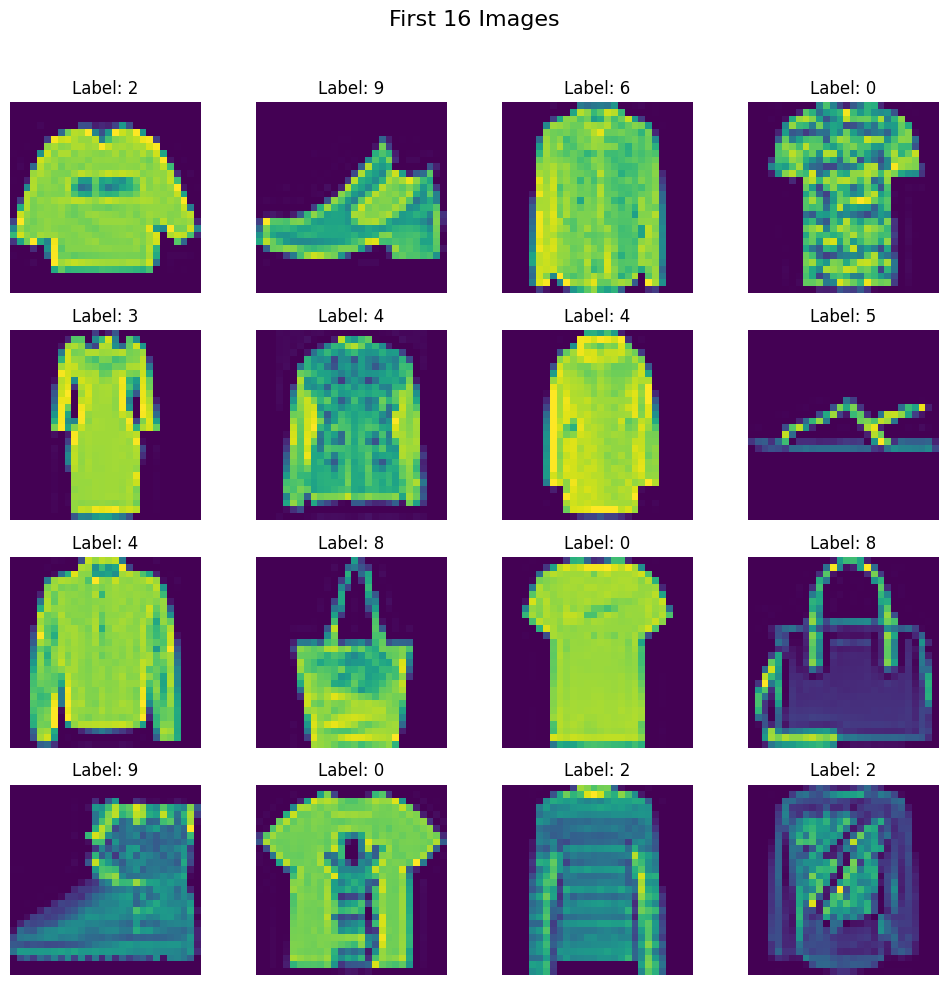

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [ ]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values


In [ ]:
# Stratify to keep class balance the same in train and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from torchvision.transforms import transforms

# Training transform: adds light augmentation to improve generalization
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test/validation transform: no augmentation, just deterministic preprocessing
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
from PIL import Image

class CustomDataset(Dataset):

  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):

    # resize to (28, 28)
    image = self.features[index].reshape(28,28)

    # change datatype to np.uint8
    image = image.astype(np.uint8)

    # change black&white to color -> (H,W,C) -> (C,H,W)
    image = np.stack([image]*3, axis=-1)

    # convert array to PIL image
    image = Image.fromarray(image)

    # apply transforms
    image = self.transform(image)

    # return
    return image, torch.tensor(self.labels[index], dtype=torch.long)


In [ ]:
# Note: train_dataset now uses the augmented transform, test_dataset uses the clean one
train_dataset = CustomDataset(X_train, y_train, transform=train_transform)
test_dataset = CustomDataset(X_test, y_test, transform=test_transform)


In [ ]:
# Improvement: larger batch size + num_workers for faster, more stable training
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False,
                          pin_memory=True, num_workers=2)


In [ ]:
# fetch the pretrained model
import torchvision.models as models

vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 160MB/s]


In [ ]:
vgg16


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Freeze all conv layers first...
for param in vgg16.features.parameters():
    param.requires_grad = False

# ...then unfreeze the last TWO conv blocks (index 17 onward) for fine-tuning.
# (Improvement 3b: originally only the last block (24:) was unfrozen. Unfreezing
# one more block gives the model more capacity to adapt VGG's ImageNet filters
# to Fashion-MNIST's very different, simple grayscale shapes -- this is usually
# the single biggest lever for both accuracy AND prediction confidence, since a
# backbone that's still 'seeing' ImageNet-style features tends to stay unsure.)
for param in vgg16.features[17:].parameters():
    param.requires_grad = True

# Sanity check: how many trainable params in the backbone now?
trainable = sum(p.numel() for p in vgg16.features.parameters() if p.requires_grad)
total = sum(p.numel() for p in vgg16.features.parameters())
print(f"Backbone trainable params: {trainable:,} / {total:,}")


Backbone trainable params: 12,979,200 / 14,714,688


In [ ]:
# Improvement 3c: BatchNorm after each Linear layer stabilizes activations
# going into ReLU/Dropout, which tends to speed up convergence and reduce
# overconfident-but-wrong OR underconfident predictions caused by unstable
# activation scales early in training.
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)


In [ ]:
vgg16 = vgg16.to(device)


In [ ]:
# Improvement 4b: more epochs, but training loop below now has early stopping
# so it will stop automatically once val accuracy stops improving -- no risk
# of wasting compute or overfitting by training too long.
epochs = 30
early_stop_patience = 6

backbone_params = [p for p in vgg16.features.parameters() if p.requires_grad]
classifier_params = vgg16.classifier.parameters()

# Improvement 6: label_smoothing softens the hard 0/1 targets slightly (e.g.
# 0.9 instead of 1.0 for the correct class). This is one of the most direct
# fixes for a model whose *confidence* is off -- it discourages the softmax
# from becoming overconfident on training data, which in turn keeps its
# confidence estimates more honest (better calibrated) on new images.
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam([
    {"params": backbone_params, "lr": 1e-5},   # small LR for fine-tuned conv layers
    {"params": classifier_params, "lr": 1e-4}  # larger LR for the new classifier head
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


In [ ]:
history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_state = None
epochs_without_improvement = 0  # for early stopping

for epoch in range(epochs):

    # ---- training ----
    vgg16.train()
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = vgg16(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()
        # NOTE: no `break` here anymore -- every batch in the epoch is used

    avg_train_loss = total_epoch_loss / len(train_loader)

    # ---- validation ----
    vgg16.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = vgg16(batch_features)
            loss = criterion(outputs, batch_labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += batch_labels.shape[0]
            correct += (predicted == batch_labels).sum().item()

    avg_val_loss = val_loss / len(test_loader)
    val_acc = correct / total

    scheduler.step(avg_val_loss)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    # keep the best-performing weights seen so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = pycopy.deepcopy(vgg16.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch+1}/{epochs} | "
          f"train_loss: {avg_train_loss:.4f} | "
          f"val_loss: {avg_val_loss:.4f} | "
          f"val_acc: {val_acc:.4f}")

    # Improvement 7: early stopping. If val accuracy hasn't improved for
    # `early_stop_patience` epochs in a row, stop -- this lets us safely set
    # `epochs` high without wasting time or overfitting once progress stalls.
    if epochs_without_improvement >= early_stop_patience:
        print(f"\nEarly stopping: no improvement for {early_stop_patience} epochs.")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# restore the best checkpoint before final evaluation
vgg16.load_state_dict(best_state)


/tmp/ipykernel_1661/2272600032.py:19: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Epoch 1/30 | train_loss: 1.1290 | val_loss: 0.8525 | val_acc: 0.8498


/tmp/ipykernel_1661/2272600032.py:19: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Epoch 2/30 | train_loss: 0.8410 | val_loss: 0.7814 | val_acc: 0.8856


/tmp/ipykernel_1661/2272600032.py:19: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


...

/tmp/ipykernel_1661/2272600032.py:19: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Epoch 19/30 | train_loss: 0.5601 | val_loss: 0.7413 | val_acc: 0.8985


/tmp/ipykernel_1661/2272600032.py:19: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Epoch 20/30 | train_loss: 0.5553 | val_loss: 0.7436 | val_acc: 0.8977

Early stopping: no improvement for 6 epochs.

Best validation accuracy: 0.9091


<All keys matched successfully>

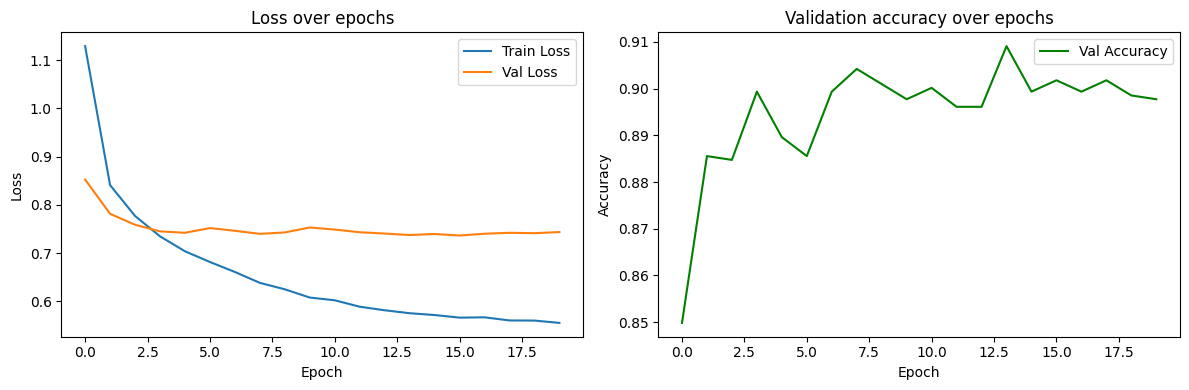

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Val Accuracy", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation accuracy over epochs")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
vgg16.eval()


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# evaluation on test data (using the best checkpoint restored above)
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(f"Test accuracy: {correct/total:.4f}")


/tmp/ipykernel_1661/2272600032.py:19: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Test accuracy: 0.9091


/tmp/ipykernel_1661/2272600032.py:19: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Avg confidence on CORRECT predictions:   0.8698
Avg confidence on INCORRECT predictions: 0.6474

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.87      0.87       129
     Trouser       1.00      0.99      1.00       123
    Pullover       0.83      0.84      0.84       120
       Dress       0.89      0.94      0.92       125
        Coat       0.85      0.91      0.88       121
      Sandal       0.95      0.99      0.97       123
       Shirt       0.76      0.69      0.72       126
     Sneaker       0.97      0.94      0.95       127
         Bag       0.98      0.96      0.97       118
  Ankle boot       0.97      0.97      0.97       120

    accuracy                           0.91      1232
   macro avg       0.91      0.91      0.91      1232
weighted avg       0.91      0.91      0.91      1232



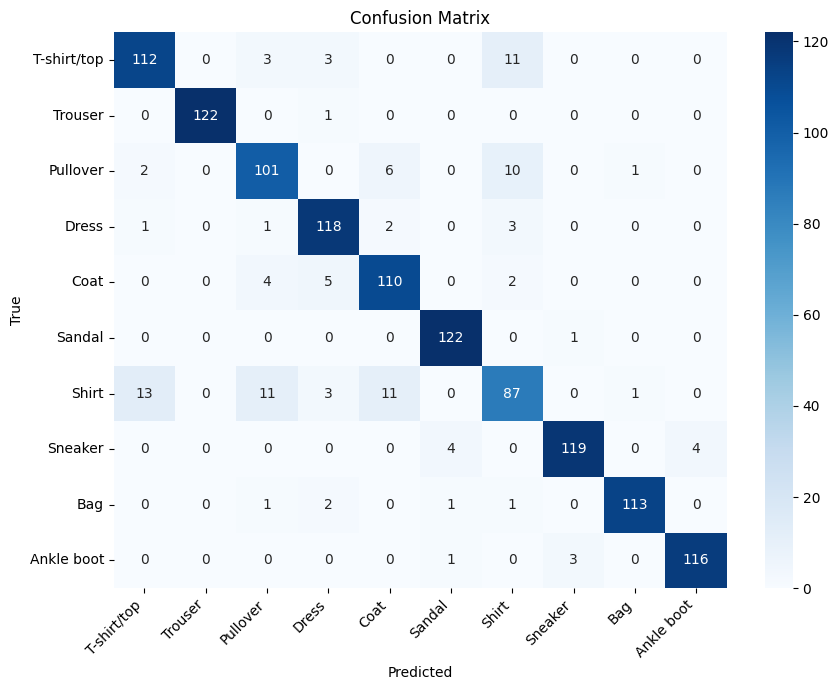

In [ ]:
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

all_preds, all_labels, all_confidences = [], [], []

vgg16.eval()
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = vgg16(batch_features)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())
        all_confidences.extend(confidence.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

correct_mask = all_preds == all_labels
print(f"Avg confidence on CORRECT predictions:   {all_confidences[correct_mask].mean():.4f}")
print(f"Avg confidence on INCORRECT predictions: {all_confidences[~correct_mask].mean():.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(f"Train accuracy: {correct/total:.4f}")


Train accuracy: 0.9974


In [ ]:
# Save the best model
torch.save(best_state, 'transfer_learning_model.pth')
print("Best model saved successfully!")


Best model saved successfully!
